# Credit Card Fraud Detection

**Module:** M606 Machine Learning  
**Professor:** Mohammad Mahdavi  
**Student Name:** Arun Singh Chauhan  
**Student ID:** GH1052389  
**Dataset:** https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud  
**GitHub:** https://github.com/Arun-Singh-Chauhan-09/m606-fraud-detection-pipeline.git

---

## Problem Statement

### Business Problem
Credit card fraud is one of those problems that sounds straightforward — a transaction is either fraudulent or it isn't — but in practice it is surprisingly difficult to catch. Global card fraud losses surpassed $33 billion in 2023, and the damage goes beyond money: every false alarm that blocks a legitimate purchase chips away at customer trust.

### Why It Matters
An automated detection system can screen millions of transactions per day instantly — something no human team could manage. Even a modest improvement in the catch rate translates into millions saved annually.

### Data Collection
In a real deployment, transaction records would stream in from payment gateways in real time. For this project I am using a publicly available dataset from Kaggle by the ML Group at ULB, covering two days of European credit card transactions from September 2013, with features anonymised via PCA.

### ML Formulation
This is a **binary classification** problem — `Class` is `1` for fraud and `0` for genuine. The features `V1`–`V28` are PCA-transformed, with `Time` and `Amount` as the only raw features. The goal is high Recall (catch fraud) without too many false alarms (Precision), best summarised by **F1-Score** and **PR-AUC**.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score)
from sklearn.utils import resample
import joblib

plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

## 2. Load Dataset

In [2]:
!pip install kaggle -q
!kaggle datasets download -d mlg-ulb/creditcardfraud
!unzip creditcardfraud.zip

df = pd.read_csv('creditcard.csv')
df.head()

Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
100% 66.0M/66.0M [00:00<00:00, 186MB/s]

Archive:  creditcardfraud.zip
  inflating: creditcard.csv          


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.dtypes

,0
Time,float64
V1,float64
V2,float64
V3,float64
V4,float64
V5,float64
V6,float64
V7,float64
V8,float64
V9,float64


## 3. Exploratory Data Analysis (EDA)

### 3.1 Check Missing Values

In [4]:
missing = df.isnull().sum()
display(pd.DataFrame(missing, columns=['Missing Values']))

,Missing Values
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


There are **no missing values** in any of the 31 columns.

### 3.2 Check Duplicate Rows

In [5]:
dup_count = df.duplicated().sum()
display(pd.DataFrame({'Duplicate Rows': [dup_count], 'Total Rows': [len(df)], 'Duplicate %': [round(dup_count/len(df)*100, 4)]}))

,Duplicate Rows,Total Rows,Duplicate %
0,1081,284807,0.3796


There are 1081 duplicate rows

### 3.3 Summary Statistics

In [6]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


### 3.4 Class Distribution

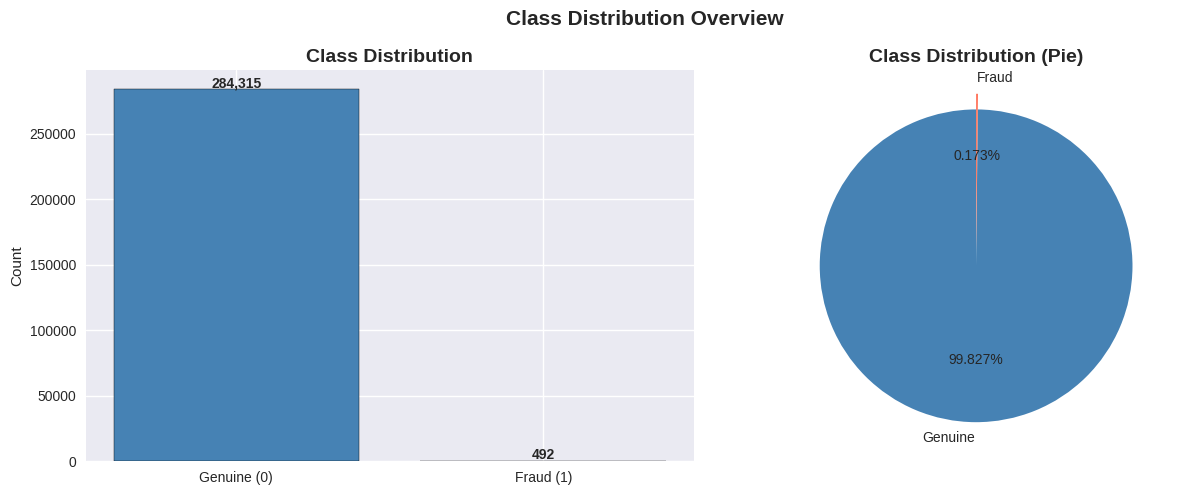

In [7]:
class_counts = df['Class'].value_counts()
class_pct    = df['Class'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(['Genuine (0)', 'Fraud (1)'], class_counts.values,
            color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(class_counts.values, labels=['Genuine', 'Fraud'],
            autopct='%1.3f%%', colors=['steelblue', 'tomato'],
            startangle=90, explode=(0, 0.1))
axes[1].set_title('Class Distribution (Pie)', fontsize=14, fontweight='bold')

plt.suptitle('Class Distribution Overview', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

Out of **284,807 transactions**, only **492 are fraudulent — roughly 0.17%**. That imbalance is extreme — a model predicting "genuine" every time would hit 99.83% accuracy while catching zero fraud. This is why I focus on **F1-Score** and **PR-AUC** rather than accuracy throughout.

### 3.5 Transaction Amount Distribution

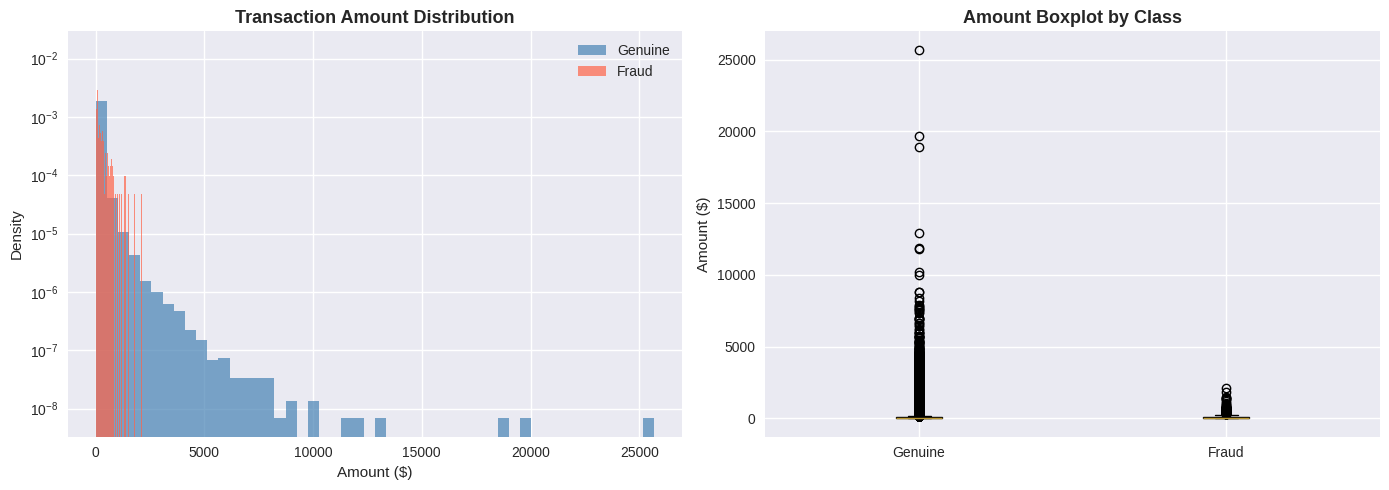

In [8]:
genuine_amt = df[df['Class'] == 0]['Amount']
fraud_amt   = df[df['Class'] == 1]['Amount']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(genuine_amt, bins=50, color='steelblue', alpha=0.7, label='Genuine', density=True)
axes[0].hist(fraud_amt,   bins=50, color='tomato',    alpha=0.7, label='Fraud',   density=True)
axes[0].set_title('Transaction Amount Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].set_yscale('log')

axes[1].boxplot([genuine_amt, fraud_amt], labels=['Genuine', 'Fraud'],
                patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[1].set_title('Amount Boxplot by Class', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Amount ($)')

plt.tight_layout()
plt.show()

### 3.8 Correlation Matrix

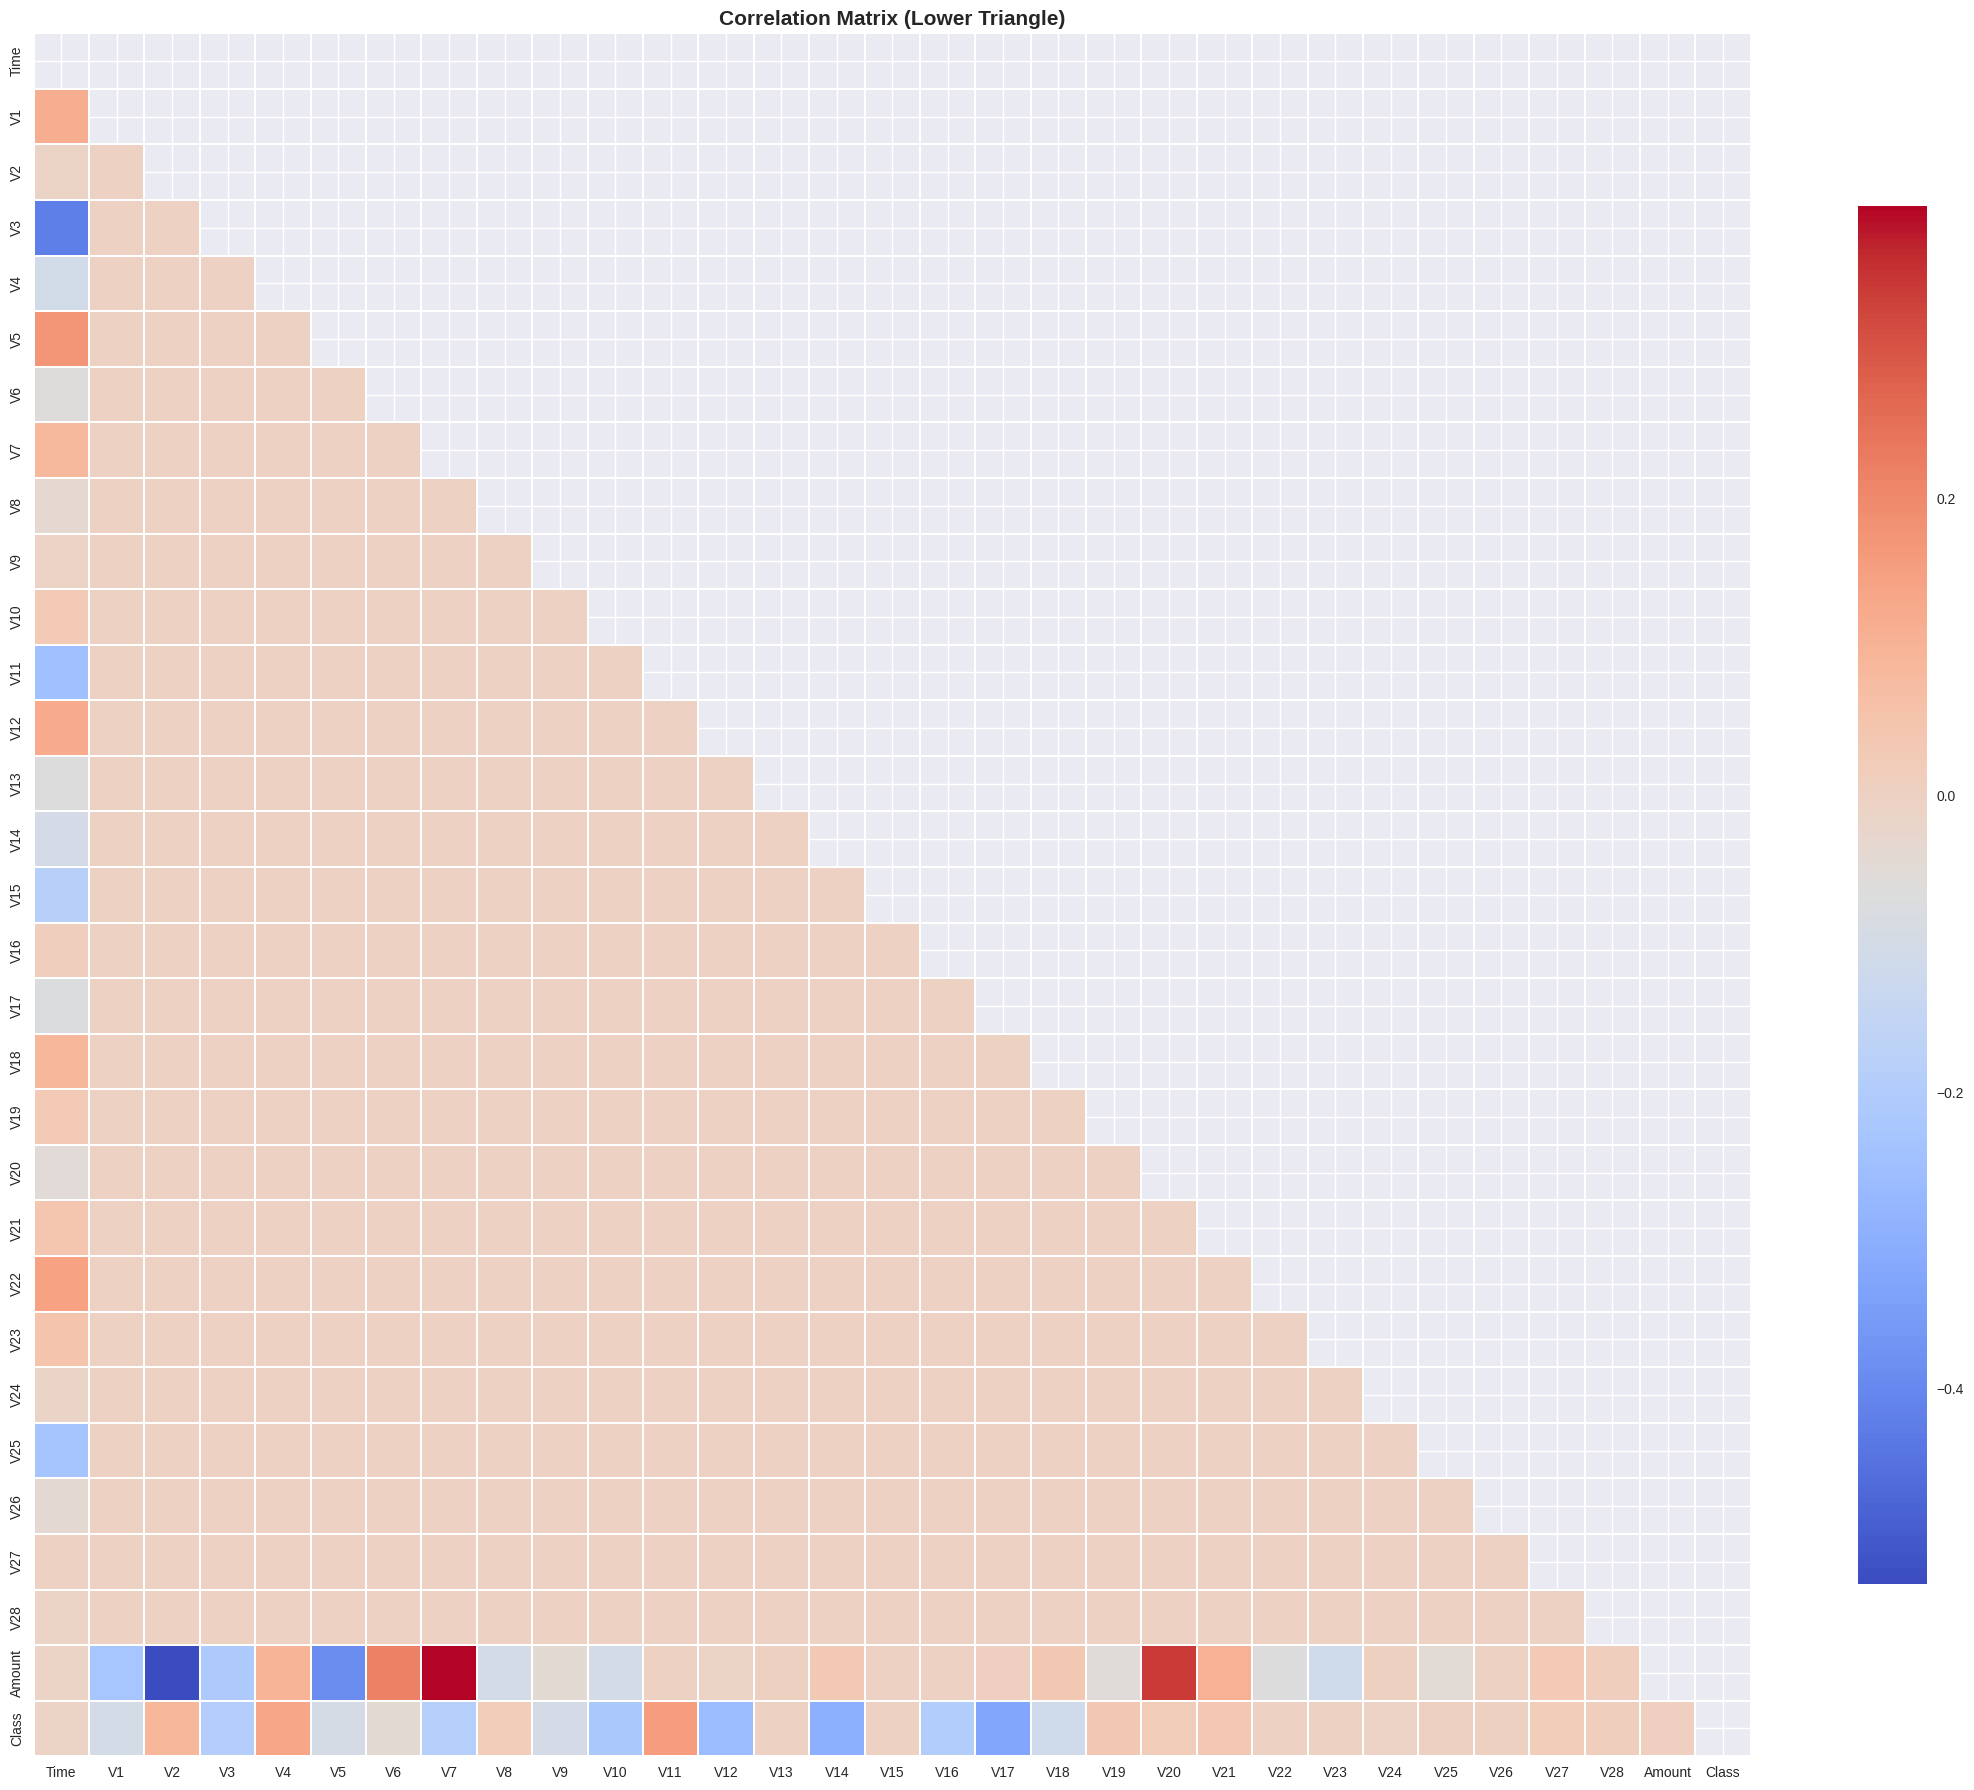

In [9]:
plt.figure(figsize=(22, 18))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm',
            linewidths=0.3, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix (Lower Triangle)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.9 Top Features Correlated with Class

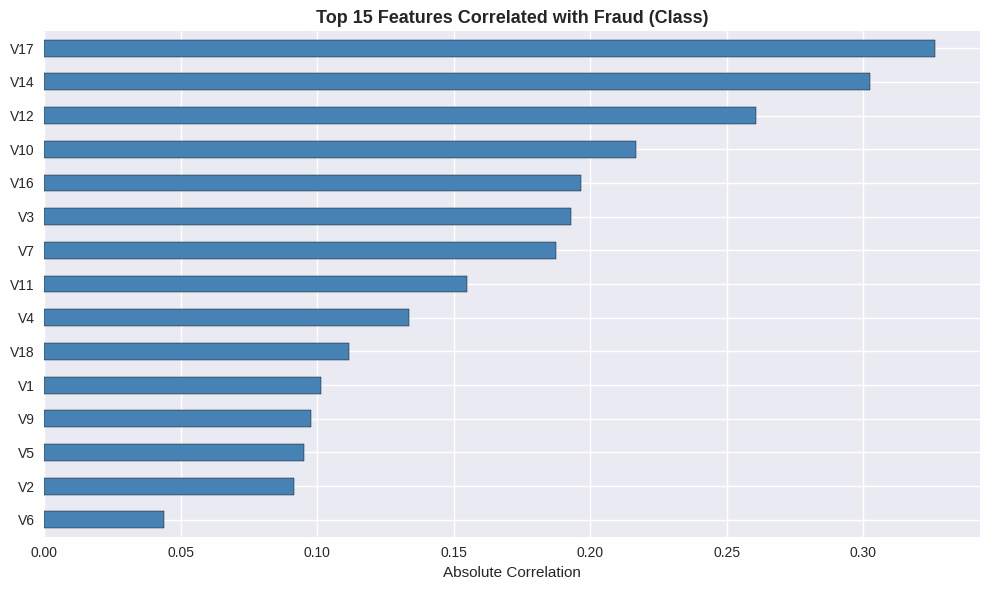

In [10]:
corr_class = df.corr()['Class'].drop('Class').abs().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
corr_class.head(15).sort_values().plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Top 15 Features Correlated with Fraud (Class)', fontsize=13, fontweight='bold')
plt.xlabel('Absolute Correlation')
plt.tight_layout()
plt.show()

`V17`, `V14`, `V12`, and `V10` are the most strongly (negatively) correlated with fraud, while `V4` and `V11` are the strongest positive predictors. `Amount` and `Time` have quite low direct correlation with `Class`, though that does not mean they are useless — tree-based models can pick up non-linear relationships that a simple correlation coefficient would miss.

## 4. Data Preprocessing

### 4.1 Handle Missing Values

As the EDA confirmed, there are no missing values in this dataset.

### 4.2 Remove Duplicates

The EDA found **1,081 duplicate rows**. I drop them here with `drop_duplicates()`

In [11]:
before = len(df)
df = df.drop_duplicates()
after  = len(df)

### 4.3 Encode Categorical Variables

There are no categorical variables in this dataset — everything is already numeric. `V1`–`V28` are the PCA components, and `Time` and `Amount` are continuous. No encoding is needed. The `Class` column is the label we are predicting, so it gets separated out into `y`.

### 4.4 Feature Scaling (StandardScaler on Time & Amount)

The PCA features `V1`–`V28` already have similar scale, but `Time` ranges from 0 to 172,792 seconds and `Amount` goes up to €25,691. That kind of mismatch can cause real problems for Logistic Regression, where the optimiser treats large-valued features as more important just because their numbers are bigger. I apply `StandardScaler` to bring `Time` and `Amount` to zero mean and unit variance. Tree-based models are technically scale-invariant, but standardising keeps the pipeline consistent.

In [12]:
scaler = StandardScaler()

df.dropna(inplace=True)

X = df.drop(['Class'], axis=1).copy()
y = df['Class']

X[['Time', 'Amount']] = scaler.fit_transform(X[['Time', 'Amount']])

### 4.5 Split into Features (X) and Target (y)

`X` contains all 30 feature columns (`Time`, `V1`–`V28`, `Amount`) after scaling. `y` is the binary target — 0 for genuine, 1 for fraud.

### 4.6 Train-Test Split (80/20 Stratified)

I use an 80/20 split with `stratify=y` to ensure the 0.17% fraud rate is preserved in both sets.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### 4.7 Handle Class Imbalance (Oversampling Minority Class)

With fraud at just 0.17%, any model trained on raw data will default to predicting "genuine" almost always. I tackle this two ways:

1. **`class_weight='balanced'`** on all classifiers — penalises mistakes on the minority class proportionally.
2. **Random oversampling** with `sklearn.utils.resample` — duplicates fraud rows in the training set until classes are balanced. Done **after** the train-test split to avoid leakage.



In [14]:
X_train_df = X_train.copy()
X_train_df['Class'] = y_train.values

fraud_train   = X_train_df[X_train_df['Class'] == 1]
genuine_train = X_train_df[X_train_df['Class'] == 0]

fraud_upsampled = resample(fraud_train, replace=True,
                            n_samples=len(genuine_train), random_state=42)

train_balanced = pd.concat([genuine_train, fraud_upsampled])
X_train_bal = train_balanced.drop('Class', axis=1)
y_train_bal = train_balanced['Class']

## 5. Model Training

I train three models, from simple to complex:

- **Logistic Regression** — fast, linear, interpretable baseline.
- **Decision Tree** — non-linear, easy to explain, but prone to overfitting.
- **Random Forest** — ensemble of trees, more robust and generally more accurate.

### 5.1 Logistic Regression

In [15]:
lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_model.fit(X_train_bal, y_train_bal)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

### 5.2 Decision Tree Classifier

In [16]:
dt_model = DecisionTreeClassifier(random_state=42, class_weight='balanced')
dt_model.fit(X_train_bal, y_train_bal)

DecisionTreeClassifier(class_weight='balanced', random_state=42)

### 5.3 Random Forest Classifier

In [17]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42,
                                   class_weight='balanced', n_jobs=-1)
rf_model.fit(X_train_bal, y_train_bal)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

## 6. Hyperparameter Tuning

I use `RandomizedSearchCV` with **Stratified K-Fold** and **F1** as the scoring metric — not accuracy — because of the class imbalance. Tuning runs on a 10% subsample to keep it fast, then the best model is retrained on the full training set.

### 6.1 Tune Logistic Regression (RandomizedSearchCV)

In [18]:
lr_params = {'C': [0.01, 0.1, 1, 10], 'solver': ['lbfgs', 'saga']}

X_sample, _, y_sample, _ = train_test_split(
    X_train_bal, y_train_bal,
    train_size=0.1,
    random_state=42,
    stratify=y_train_bal
)

lr_grid = RandomizedSearchCV(
    LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    lr_params,
    n_iter=5,
    cv=StratifiedKFold(n_splits=2),
    scoring='f1',
    n_jobs=-1,
    random_state=42
)

lr_grid.fit(X_sample, y_sample)
best_lr = lr_grid.best_estimator_
best_lr.fit(X_train_bal, y_train_bal)

LogisticRegression(C=1, class_weight='balanced', max_iter=1000, random_state=42,
                   solver='saga')

### 6.2 Tune Decision Tree (RandomizedSearchCV)

In [19]:
dt_params = {
    'max_depth'        : [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4]
}

X_sample, _, y_sample, _ = train_test_split(
    X_train_bal, y_train_bal,
    train_size=0.1,
    random_state=42,
    stratify=y_train_bal
)

dt_grid = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    dt_params,
    n_iter=5,
    cv=StratifiedKFold(n_splits=2),
    scoring='f1',
    n_jobs=-1,
    random_state=42
)
dt_grid.fit(X_sample, y_sample)
best_dt = dt_grid.best_estimator_
best_dt.fit(X_train_bal, y_train_bal)

DecisionTreeClassifier(class_weight='balanced', min_samples_leaf=2,
                       random_state=42)

### 6.3 Tune Random Forest (RandomizedSearchCV)

In [20]:
rf_params = {
    'n_estimators'     : [50, 100],
    'max_depth'        : [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf' : [1, 2]
}

X_sample, _, y_sample, _ = train_test_split(
    X_train_bal, y_train_bal,
    train_size=0.05,
    random_state=42,
    stratify=y_train_bal
)

rf_rand = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1),
    rf_params,
    n_iter=5,
    cv=2,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)
rf_rand.fit(X_sample, y_sample)
best_rf = rf_rand.best_estimator_
best_rf.fit(X_train_bal, y_train_bal)

RandomForestClassifier(class_weight='balanced', max_depth=20,
                       min_samples_leaf=2, min_samples_split=5, n_estimators=50,
                       n_jobs=-1, random_state=42)

## 7. Model Evaluation

### 7.1 Evaluation Helper Function

In [21]:
def evaluate_model(name, model, X_test, y_test):
    y_pred  = model.predict(X_test)
    y_prob  = model.predict_proba(X_test)[:, 1]

    acc     = accuracy_score(y_test, y_pred)
    prec    = precision_score(y_test, y_pred)
    rec     = recall_score(y_test, y_pred)
    f1      = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc  = average_precision_score(y_test, y_prob)
    cm      = confusion_matrix(y_test, y_pred)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Genuine','Fraud'], yticklabels=['Genuine','Fraud'])
    axes[0].set_title(f'{name}\nConfusion Matrix', fontweight='bold')
    axes[0].set_ylabel('Actual')
    axes[0].set_xlabel('Predicted')

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    axes[1].plot(fpr, tpr, lw=2, color='darkorange', label=f'ROC AUC = {roc_auc:.4f}')
    axes[1].plot([0,1],[0,1],'k--', lw=1)
    axes[1].set_title(f'{name}\nROC Curve', fontweight='bold')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].legend(loc='lower right')

    plt.tight_layout()
    plt.show()

    return {'Model': name, 'Accuracy': acc, 'Precision': prec,
            'Recall': rec, 'F1-Score': f1, 'ROC-AUC': roc_auc, 'PR-AUC': pr_auc}

### 7.2 Evaluate Logistic Regression

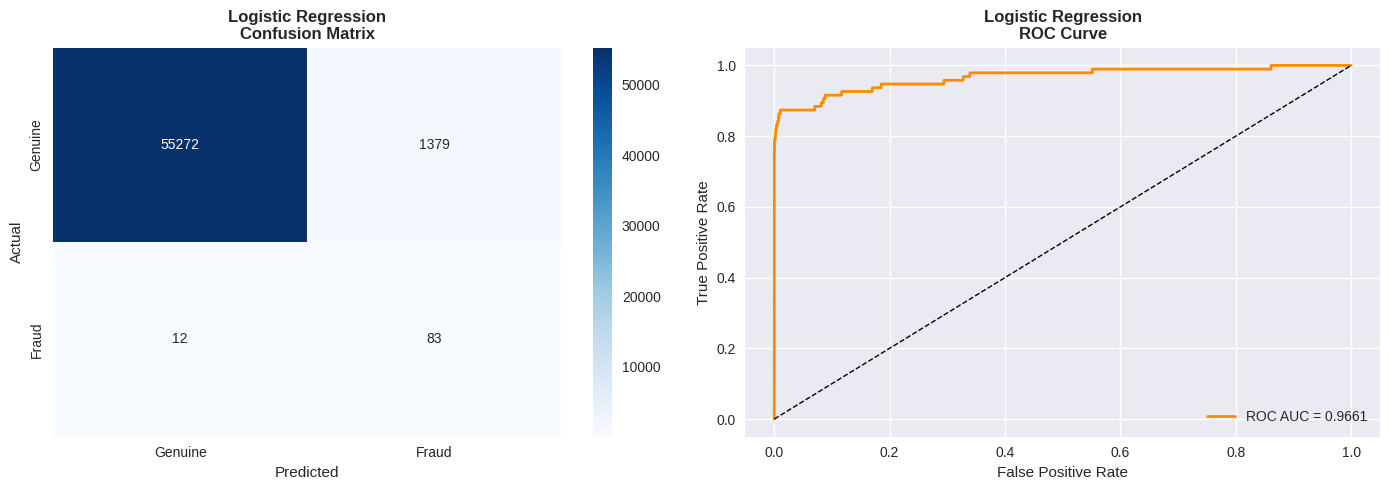

In [22]:
results = []
results.append(evaluate_model('Logistic Regression', best_lr, X_test, y_test))

### 7.3 Evaluate Decision Tree

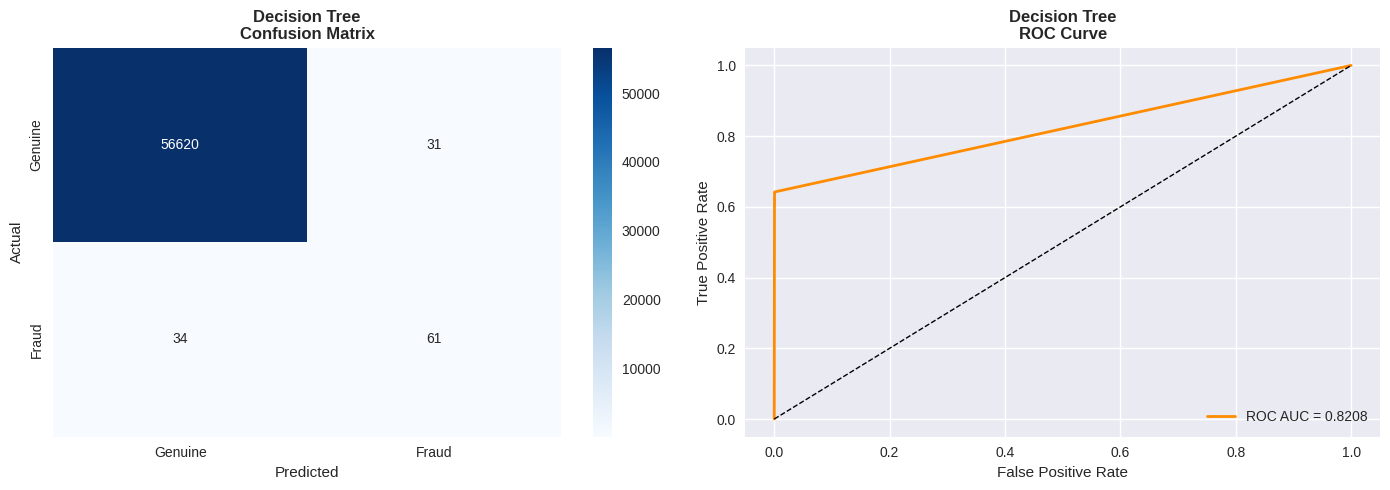

In [23]:
results.append(evaluate_model('Decision Tree', best_dt, X_test, y_test))

### 7.4 Evaluate Random Forest

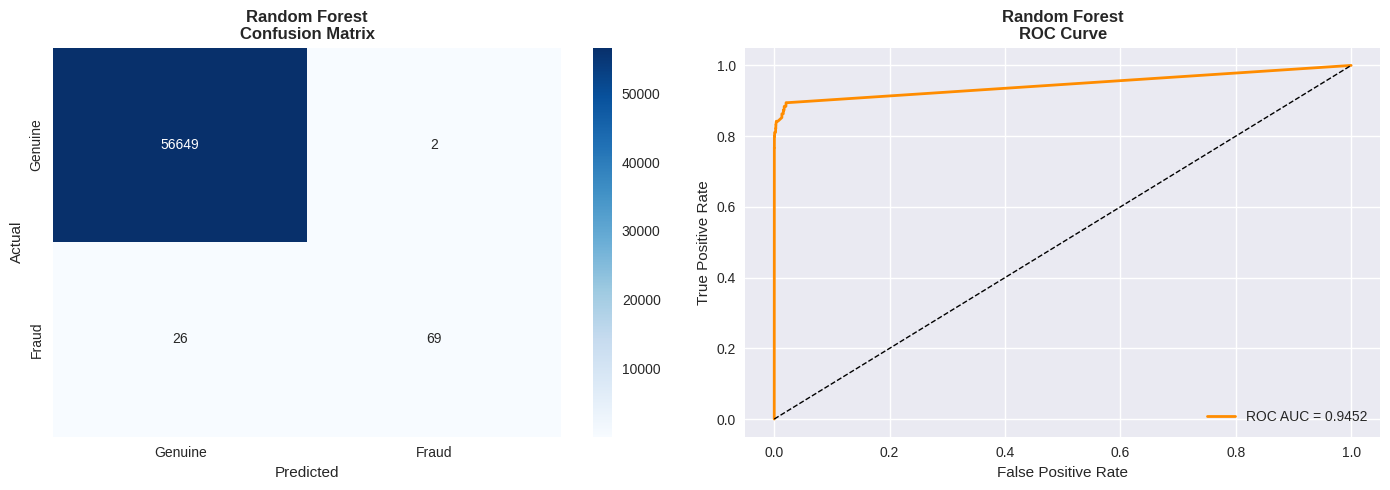

In [24]:
results.append(evaluate_model('Random Forest', best_rf, X_test, y_test))

## 8. Compare Models

### 8.1 Model Comparison Table

In [25]:
results_df = pd.DataFrame(results).set_index('Model').round(4)
results_df

,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
Model,,,,,,
Logistic Regression,0.9755,0.0568,0.8737,0.1066,0.9661,0.6737
Decision Tree,0.9989,0.6630,0.6421,0.6524,0.8208,0.4574
Random Forest,0.9995,0.9718,0.7263,0.8313,0.9452,0.8004


### 8.2 Visual Comparison

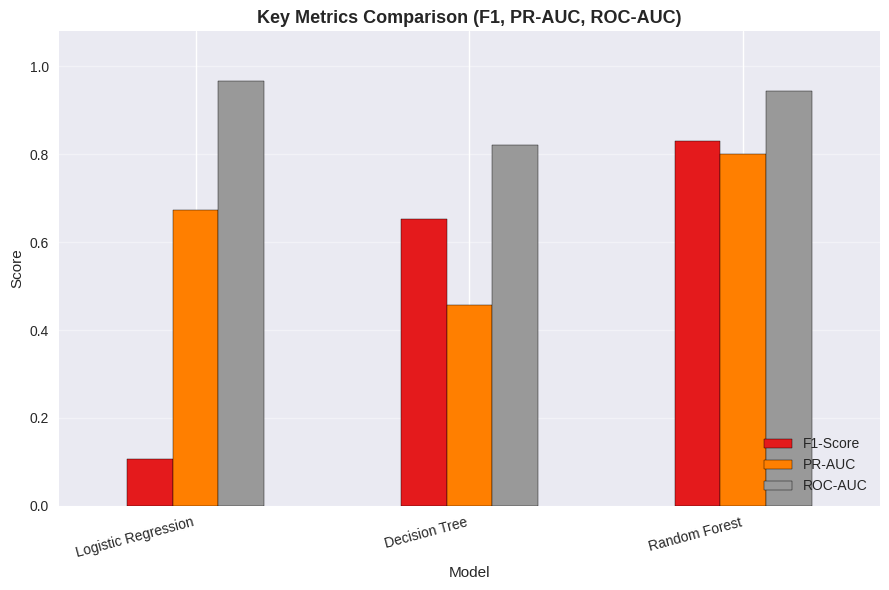

In [26]:
results_df[['F1-Score','PR-AUC','ROC-AUC']].plot(
    kind='bar', figsize=(9, 6), edgecolor='black', colormap='Set1'
)
plt.title('Key Metrics Comparison (F1, PR-AUC, ROC-AUC)', fontsize=13, fontweight='bold')
plt.ylabel('Score')
plt.ylim(0, 1.08)
plt.xticks(rotation=15, ha='right')
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

### 8.3 Combined ROC Curves

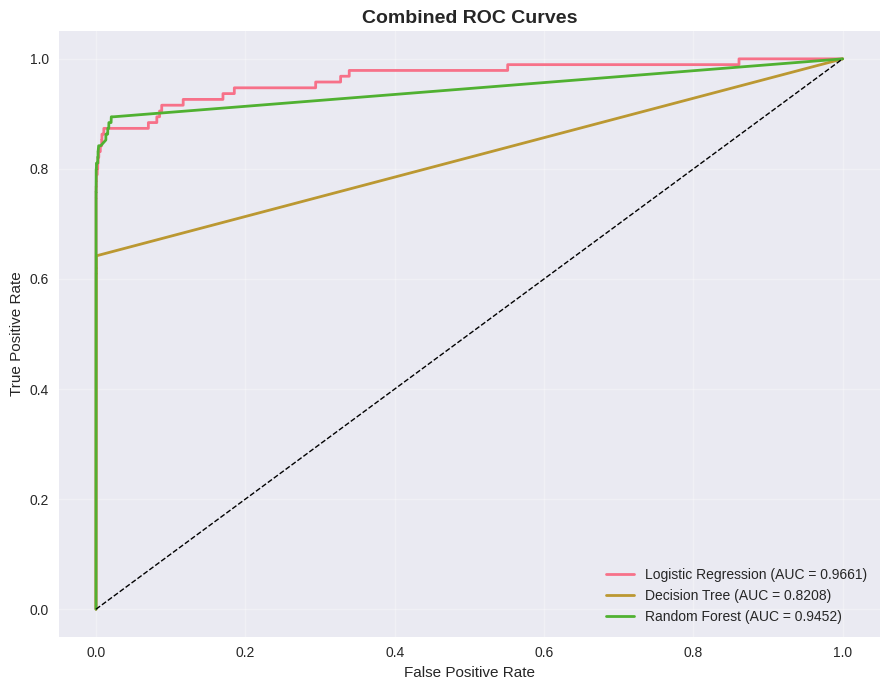

In [27]:
plt.figure(figsize=(9, 7))
for name, model in [('Logistic Regression', best_lr),
                     ('Decision Tree', best_dt),
                     ('Random Forest', best_rf)]:
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {auc:.4f})')

plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Combined ROC Curves', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 8.4 Combined Precision-Recall Curves (AUPRC)

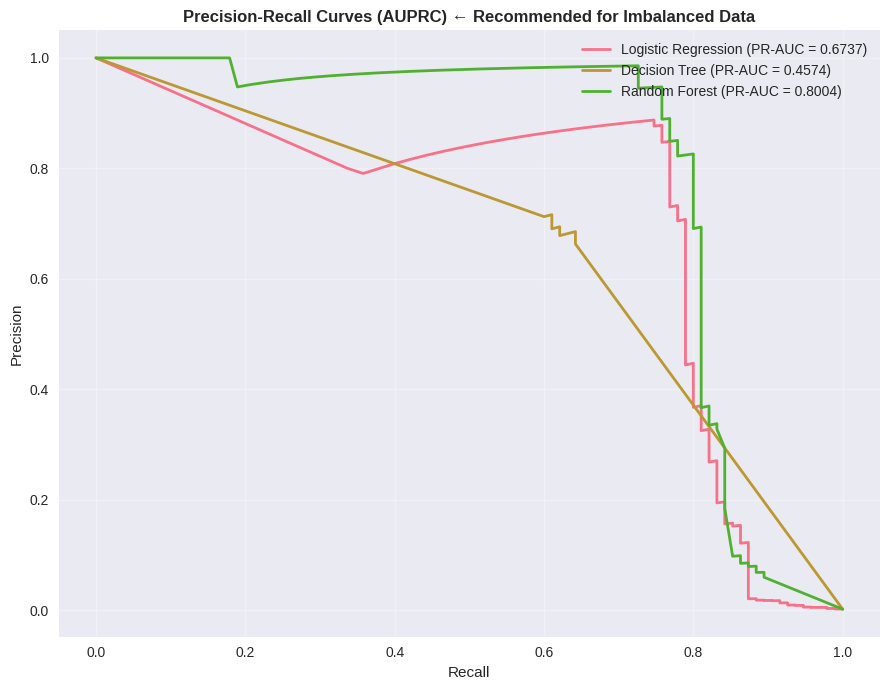

In [28]:
plt.figure(figsize=(9, 7))
for name, model in [('Logistic Regression', best_lr),
                     ('Decision Tree', best_dt),
                     ('Random Forest', best_rf)]:
    y_prob = model.predict_proba(X_test)[:, 1]
    prec_vals, rec_vals, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)
    plt.plot(rec_vals, prec_vals, lw=2, label=f'{name} (PR-AUC = {pr_auc:.4f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves (AUPRC) ← Recommended for Imbalanced Data',
          fontsize=12, fontweight='bold')
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Feature Importance

### 9.1 Random Forest Feature Importance

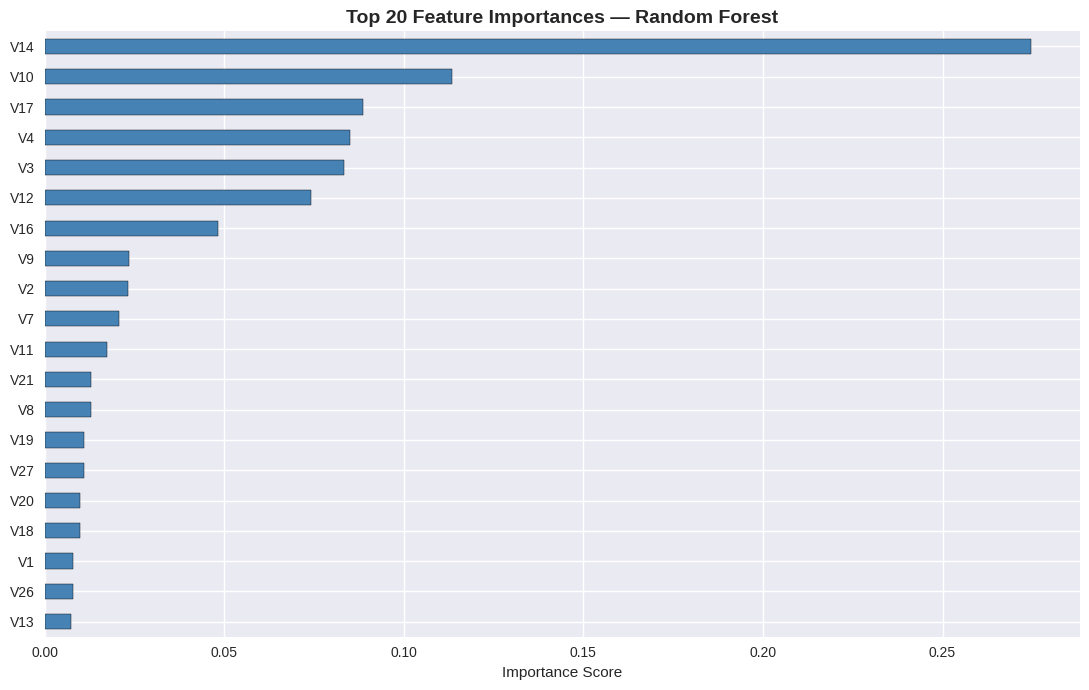

In [29]:
feature_imp = pd.Series(best_rf.feature_importances_,
                         index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(11, 7))
feature_imp.head(20).sort_values().plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Top 20 Feature Importances — Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## 10. Final Model Selection

### 10.1 Choose Best Model

In [30]:
best_model_name = results_df['F1-Score'].idxmax()
display(pd.DataFrame({'Best Model': [best_model_name]}))

,Best Model
0,Random Forest


### 10.2 Retrain Best Model on Full Balanced Training Data

In [31]:
model_map = {
    'Logistic Regression': best_lr,
    'Decision Tree'      : best_dt,
    'Random Forest'      : best_rf
}
final_model = model_map[best_model_name]
final_model.fit(X_train_bal, y_train_bal)

RandomForestClassifier(class_weight='balanced', max_depth=20,
                       min_samples_leaf=2, min_samples_split=5, n_estimators=50,
                       n_jobs=-1, random_state=42)

### 10.3 Final Evaluation on Test Set

In [32]:
y_pred_final = final_model.predict(X_test)
y_prob_final = final_model.predict_proba(X_test)[:, 1]

pd.DataFrame(
    [accuracy_score(y_test, y_pred_final),
     precision_score(y_test, y_pred_final),
     recall_score(y_test, y_pred_final),
     f1_score(y_test, y_pred_final),
     roc_auc_score(y_test, y_prob_final),
     average_precision_score(y_test, y_prob_final)],
    index=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC'],
    columns=['Score']
).round(4)

,Score
Accuracy,0.9995
Precision,0.9718
Recall,0.7263
F1-Score,0.8313
ROC-AUC,0.9452
PR-AUC,0.8004


### 10.4 Save Final Model

In [33]:
joblib.dump(final_model, 'best_fraud_detection_model.pkl')

['best_fraud_detection_model.pkl']

### 10.5 Testing — Load Saved Model & Predict on Sample Data

In [34]:
loaded_model = joblib.load('best_fraud_detection_model.pkl')

sample_genuine = X_test[y_test == 0].iloc[:5]
sample_fraud   = X_test[y_test == 1].iloc[:5]
sample_test    = pd.concat([sample_genuine, sample_fraud])
true_labels    = [0]*5 + [1]*5

preds = loaded_model.predict(sample_test)
probs = loaded_model.predict_proba(sample_test)[:, 1]

pd.DataFrame({
    'True Label' : ['Genuine' if t == 0 else 'Fraud' for t in true_labels],
    'Predicted'  : ['Genuine' if p == 0 else 'Fraud' for p in preds],
    'Fraud Prob' : probs.round(4),
    'Result'     : ['CORRECT' if t == p else 'WRONG' for t, p in zip(true_labels, preds)]
})

,True Label,Predicted,Fraud Prob,Result
0,Genuine,Genuine,0.0000,CORRECT
1,Genuine,Genuine,0.0000,CORRECT
2,Genuine,Genuine,0.0000,CORRECT
3,Genuine,Genuine,0.0000,CORRECT
4,Genuine,Genuine,0.0000,CORRECT
5,Fraud,Fraud,0.9199,CORRECT
6,Fraud,Fraud,0.8995,CORRECT
7,Fraud,Genuine,0.0596,WRONG
8,Fraud,Fraud,0.9197,CORRECT
9,Fraud,Genuine,0.0000,WRONG


---

## 11. Final Discussion

### Strengths and Limitations
- Used F1 and PR-AUC from the start — accuracy would've been useless at 0.17% fraud
- Oversampling stayed inside training only, so test results are honest
- Compared three models properly rather than just picking one
- Random oversampling is the weak point — it just copies rows, SMOTE would be better
- A time-based split would reflect real deployment better than a random one

### Implications for the Business Problem
- High Recall = more fraud caught = less money lost
- High Precision = fewer blocked legitimate transactions = happier customers

### Data-Driven Recommendations
1. Deploy Random Forest as the live scoring model
2. Don't use 0.5 as the threshold — tune it to actual fraud costs
3. Watch PR-AUC over time and retrain when it dips
4. Add simple rule-based checks on top for obvious red flags

### Most Informative Features
- `V17`, `V14`, `V12`, `V10` are the strongest fraud predictors
- Consistent with the EDA correlation plot
- `Amount` also matters

### Is the Model Explainable?
- Logistic Regression: yes, coefficients are directly interpretable
- Random Forest: not at prediction level, but feature importances help

### Will I Deploy the Model?
- Yes — it's saved via `joblib` and ready for a REST API
